In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/AcTBeCalf.csv')

In [3]:
df.head()

,dateTime,calfId,accX,accY,accZ,behaviour,segId
0,2022-02-24 00:08:34.402385,1306,0.812500,0.390625,0.281250,oral_manipulation_of_pen,0
1,2022-02-24 00:08:34.441385,1306,0.687500,0.375000,0.375000,oral_manipulation_of_pen,0
2,2022-02-24 00:08:34.481386,1306,0.625000,0.296875,0.265625,oral_manipulation_of_pen,0
3,2022-02-24 00:08:34.521386,1306,0.703125,0.218750,0.218750,oral_manipulation_of_pen,0
4,2022-02-24 00:08:34.560387,1306,0.734375,0.218750,0.250000,oral_manipulation_of_pen,0


## **EDA**

In [4]:
df.shape

(2467162, 7)

In [5]:
df.isnull().sum()

,0
dateTime,0
calfId,0
accX,0
accY,0
accZ,0
behaviour,0
segId,0


In [6]:
df.dtypes

,0
dateTime,object
calfId,int64
accX,float64
accY,float64
accZ,float64
behaviour,object
segId,int64


# **dateTime**:
- first transform the column to date time format.
- lets separate the date and time to different columns.
- 21 dates in the range 04-02-2022 and 31-03-2022.
- most of the time difference is in between 0.038 to 0.042 with some extreme outliers

In [7]:
df['dateTime']

,dateTime
0,2022-02-24 00:08:34.402385
1,2022-02-24 00:08:34.441385
2,2022-02-24 00:08:34.481386
3,2022-02-24 00:08:34.521386
4,2022-02-24 00:08:34.560387
...,...
2467157,2022-02-22 20:29:29.977497
2467158,2022-02-22 20:29:30.019498
2467159,2022-02-22 20:29:30.060499
2467160,2022-02-22 20:29:30.101501


In [8]:
df['dateTime'] = pd.to_datetime(df['dateTime'])
df['date'] = df['dateTime'].dt.date
df['time'] = df['dateTime'].dt.time
df.head()

,dateTime,calfId,accX,accY,accZ,behaviour,segId,date,time
0,2022-02-24 00:08:34.402385,1306,0.812500,0.390625,0.281250,oral_manipulation_of_pen,0,2022-02-24,00:08:34.402385
1,2022-02-24 00:08:34.441385,1306,0.687500,0.375000,0.375000,oral_manipulation_of_pen,0,2022-02-24,00:08:34.441385
2,2022-02-24 00:08:34.481386,1306,0.625000,0.296875,0.265625,oral_manipulation_of_pen,0,2022-02-24,00:08:34.481386
3,2022-02-24 00:08:34.521386,1306,0.703125,0.218750,0.218750,oral_manipulation_of_pen,0,2022-02-24,00:08:34.521386
4,2022-02-24 00:08:34.560387,1306,0.734375,0.218750,0.250000,oral_manipulation_of_pen,0,2022-02-24,00:08:34.560387


In [9]:
df['date'].value_counts().sort_index()

,count
date,
2022-02-04,52318
2022-02-05,170560
2022-02-06,111896
2022-02-07,129418
2022-02-09,45993
2022-02-10,82267
2022-02-11,30831
2022-02-12,32128
2022-02-13,80657


In [10]:
df['time_diff'] = df.groupby('date')['dateTime'].diff().dt.total_seconds()

In [11]:
df.head()

,dateTime,calfId,accX,accY,accZ,behaviour,segId,date,time,time_diff
0,2022-02-24 00:08:34.402385,1306,0.812500,0.390625,0.281250,oral_manipulation_of_pen,0,2022-02-24,00:08:34.402385,NaN
1,2022-02-24 00:08:34.441385,1306,0.687500,0.375000,0.375000,oral_manipulation_of_pen,0,2022-02-24,00:08:34.441385,0.039000
2,2022-02-24 00:08:34.481386,1306,0.625000,0.296875,0.265625,oral_manipulation_of_pen,0,2022-02-24,00:08:34.481386,0.040001
3,2022-02-24 00:08:34.521386,1306,0.703125,0.218750,0.218750,oral_manipulation_of_pen,0,2022-02-24,00:08:34.521386,0.040000
4,2022-02-24 00:08:34.560387,1306,0.734375,0.218750,0.250000,oral_manipulation_of_pen,0,2022-02-24,00:08:34.560387,0.039001


In [12]:
df['time_diff'].value_counts()

,count
time_diff,
0.040001,432148
0.041001,380965
0.039001,294047
0.040000,276699
0.041000,213795
...,...
0.451010,1
5.799132,1
9.038206,1


<Axes: ylabel='Density'>

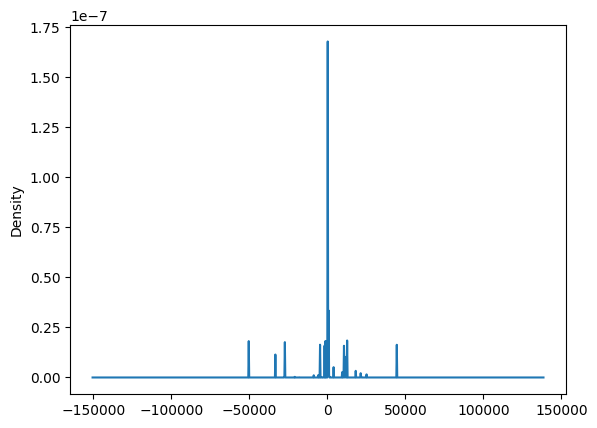

In [13]:
df['time_diff'].plot(kind='kde')

<Axes: ylabel='Density'>

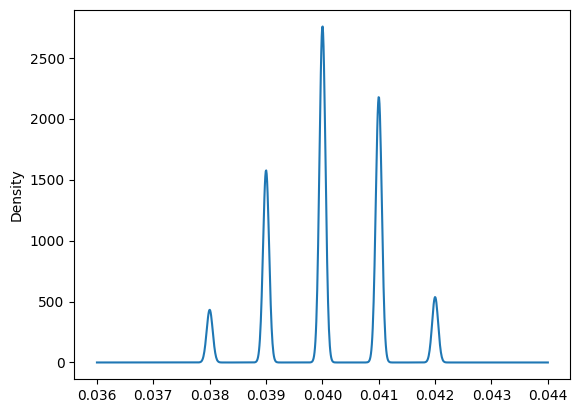

In [14]:
# Focus on the 95th percentile to remove extreme outliers
filtered_df = df[df['time_diff'].between(df['time_diff'].quantile(0.05), df['time_diff'].quantile(0.95))]
filtered_df['time_diff'].plot(kind='kde')

In [15]:
pd.options.display.float_format = '{:.4f}'.format
filtered_df['time_diff'].describe()


,time_diff
count,2386818.0000
mean,0.0401
std,0.0010
min,0.0380
25%,0.0390
50%,0.0400
75%,0.0410
max,0.0420


In [16]:
print(2467162 - 2386818.0000)

80344.0


# **calfId**

In [17]:
df['calfId'].value_counts().sort_index()

,count
calfId,
1302,137165
1303,137150
1306,107829
1308,157910
1312,98976
1314,135178
1319,97397
1320,110603
1328,50114


In [18]:
df['calfId'].value_counts().sort_index().count()

np.int64(30)

In [19]:
df.head()

,dateTime,calfId,accX,accY,accZ,behaviour,segId,date,time,time_diff
0,2022-02-24 00:08:34.402385,1306,0.8125,0.3906,0.2812,oral_manipulation_of_pen,0,2022-02-24,00:08:34.402385,NaN
1,2022-02-24 00:08:34.441385,1306,0.6875,0.3750,0.3750,oral_manipulation_of_pen,0,2022-02-24,00:08:34.441385,0.0390
2,2022-02-24 00:08:34.481386,1306,0.6250,0.2969,0.2656,oral_manipulation_of_pen,0,2022-02-24,00:08:34.481386,0.0400
3,2022-02-24 00:08:34.521386,1306,0.7031,0.2188,0.2188,oral_manipulation_of_pen,0,2022-02-24,00:08:34.521386,0.0400
4,2022-02-24 00:08:34.560387,1306,0.7344,0.2188,0.2500,oral_manipulation_of_pen,0,2022-02-24,00:08:34.560387,0.0390


# **behaviour**

In [20]:
df['behaviour'].value_counts()

,count
behaviour,
lying,965184
drinking_milk,217075
standing,188908
eating_concentrates,146067
sniff,134768
eating_bedding,129119
oral_manipulation_of_pen,118210
grooming,114181
running,83345


In [21]:
df['behaviour'].value_counts().count()

np.int64(50)

In [22]:
print(df['behaviour'].value_counts(normalize=True) * 100)

behaviour
lying                      39.1212
drinking_milk               8.7986
standing                    7.6569
eating_concentrates         5.9204
sniff                       5.4625
eating_bedding              5.2335
oral_manipulation_of_pen    4.7913
grooming                    4.6280
running                     3.3782
eating_forage               3.2599
walking                     2.7293
social_groom                1.2069
social_sniff                0.9330
headbutt                    0.7222
rumination_lying            0.6807
grooming_lying              0.4935
sniff_walking               0.4599
abnormal                    0.4419
scratch                     0.4177
social                      0.3723
drinking                    0.3686
backward                    0.3029
rub                         0.2709
rising                      0.2634
tongue_rolling              0.2393
urination                   0.2338
social_nudge                0.2296
play_object                 0.2212
sniff_lyin

In [23]:
behaviour_map = {
    # Not Active
    'lying': 'not active', 'standing': 'not active', 'rumination_lying': 'not active',
    'grooming_lying': 'not active', 'sniff_lying': 'not active', 'lying-down': 'not active',
    'social_groom_lying': 'not active', 'social_sniff_lying': 'not active',
    'social_nudge_lying': 'not active', 'rumination': 'not active', 'tongue_rolling_lying': 'not active',

    # Active
    'drinking_milk': 'active', 'eating_concentrates': 'active', 'sniff': 'active',
    'grooming': 'active', 'running': 'active', 'eating_forage': 'active',
    'walking': 'active', 'social_groom': 'active', 'social_sniff': 'active',
    'headbutt': 'active', 'sniff_walking': 'active', 'scratch': 'active',
    'social': 'active', 'drinking': 'active', 'backward': 'active',
    'rub': 'active', 'rising': 'active', 'social_nudge': 'active',
    'play_object': 'active', 'defecation': 'active', 'jump': 'active',
    'drinking|water': 'active', 'stretch': 'active', 'drinking_electrolytes': 'active',
    'eating': 'active', 'mount': 'active', 'play': 'active', 'vocalization': 'active',

    # Abnormal
    'eating_bedding': 'abnormal', 'oral_manipulation_of_pen': 'abnormal',
    'abnormal': 'abnormal', 'tongue_rolling': 'abnormal', 'cross-suckle_udder': 'abnormal',
    'cross-suckle_other': 'abnormal', 'fall': 'abnormal',

    # Other
    'urination': 'other', 'grooming|None': 'other', 'SRS': 'other', 'cough': 'other'
}

df['category'] = df['behaviour'].map(behaviour_map)

print(df['category'].isna().sum(), "unmapped items found.")


0 unmapped items found.


<Axes: xlabel='category'>

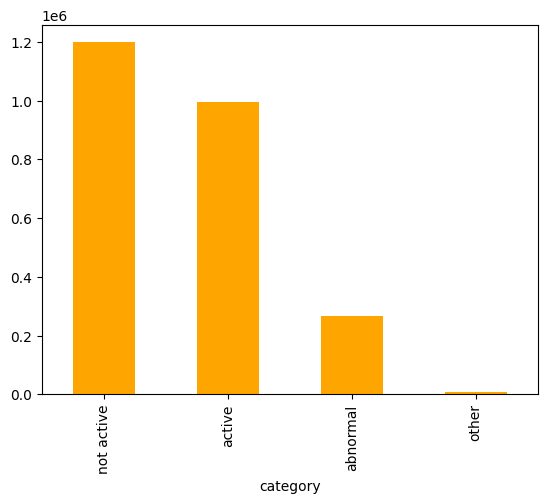

In [24]:
df['category'].value_counts().plot(kind='bar', color='orange')

accX: Accelerometer reading for the X axis (top-bottom direction).

accY: Accelerometer reading for the Y axis (backward-forward direction).

accZ: Accelerometer reading for the Z axis (left-right direction).

In [25]:
df['acc_mag'] = np.sqrt(df['accX']**2 + df['accY']**2 + df['accZ']**2)
df['energy'] = abs(df['acc_mag'] - 1.0)

In [26]:
df.head()

,dateTime,calfId,accX,accY,accZ,behaviour,segId,date,time,time_diff,category,acc_mag,energy
0,2022-02-24 00:08:34.402385,1306,0.8125,0.3906,0.2812,oral_manipulation_of_pen,0,2022-02-24,00:08:34.402385,NaN,abnormal,0.9444,0.0556
1,2022-02-24 00:08:34.441385,1306,0.6875,0.3750,0.3750,oral_manipulation_of_pen,0,2022-02-24,00:08:34.441385,0.0390,abnormal,0.8683,0.1317
2,2022-02-24 00:08:34.481386,1306,0.6250,0.2969,0.2656,oral_manipulation_of_pen,0,2022-02-24,00:08:34.481386,0.0400,abnormal,0.7412,0.2588
3,2022-02-24 00:08:34.521386,1306,0.7031,0.2188,0.2188,oral_manipulation_of_pen,0,2022-02-24,00:08:34.521386,0.0400,abnormal,0.7682,0.2318
4,2022-02-24 00:08:34.560387,1306,0.7344,0.2188,0.2500,oral_manipulation_of_pen,0,2022-02-24,00:08:34.560387,0.0390,abnormal,0.8060,0.1940


<Axes: ylabel='Density'>

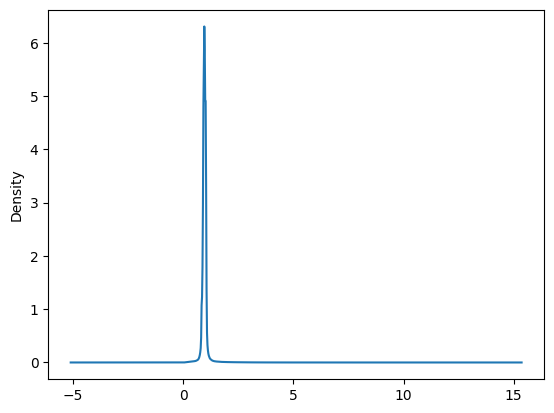

In [27]:
df['acc_mag'].plot(kind='kde')

<Axes: ylabel='Density'>

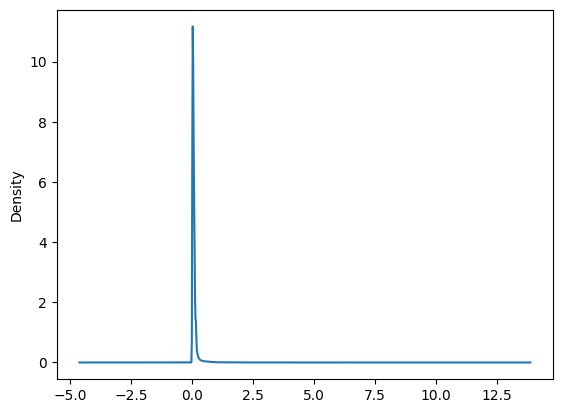

In [28]:
df['energy'].plot(kind='kde')

# **segId:**
Segment identification number associated with each accelerometer reading/row, representing all readings of the same behavior segment.

In [29]:
df['segId'].value_counts().sort_index()

,count
segId,
0,825
1,557
2,818
3,304
4,241
...,...
4011,178
4012,80
4013,92


In [30]:
df['segId'].value_counts().count()

np.int64(4016)

# **BiVariate**

In [31]:
df.head()

,dateTime,calfId,accX,accY,accZ,behaviour,segId,date,time,time_diff,category,acc_mag,energy
0,2022-02-24 00:08:34.402385,1306,0.8125,0.3906,0.2812,oral_manipulation_of_pen,0,2022-02-24,00:08:34.402385,NaN,abnormal,0.9444,0.0556
1,2022-02-24 00:08:34.441385,1306,0.6875,0.3750,0.3750,oral_manipulation_of_pen,0,2022-02-24,00:08:34.441385,0.0390,abnormal,0.8683,0.1317
2,2022-02-24 00:08:34.481386,1306,0.6250,0.2969,0.2656,oral_manipulation_of_pen,0,2022-02-24,00:08:34.481386,0.0400,abnormal,0.7412,0.2588
3,2022-02-24 00:08:34.521386,1306,0.7031,0.2188,0.2188,oral_manipulation_of_pen,0,2022-02-24,00:08:34.521386,0.0400,abnormal,0.7682,0.2318
4,2022-02-24 00:08:34.560387,1306,0.7344,0.2188,0.2500,oral_manipulation_of_pen,0,2022-02-24,00:08:34.560387,0.0390,abnormal,0.8060,0.1940


**category and energy**

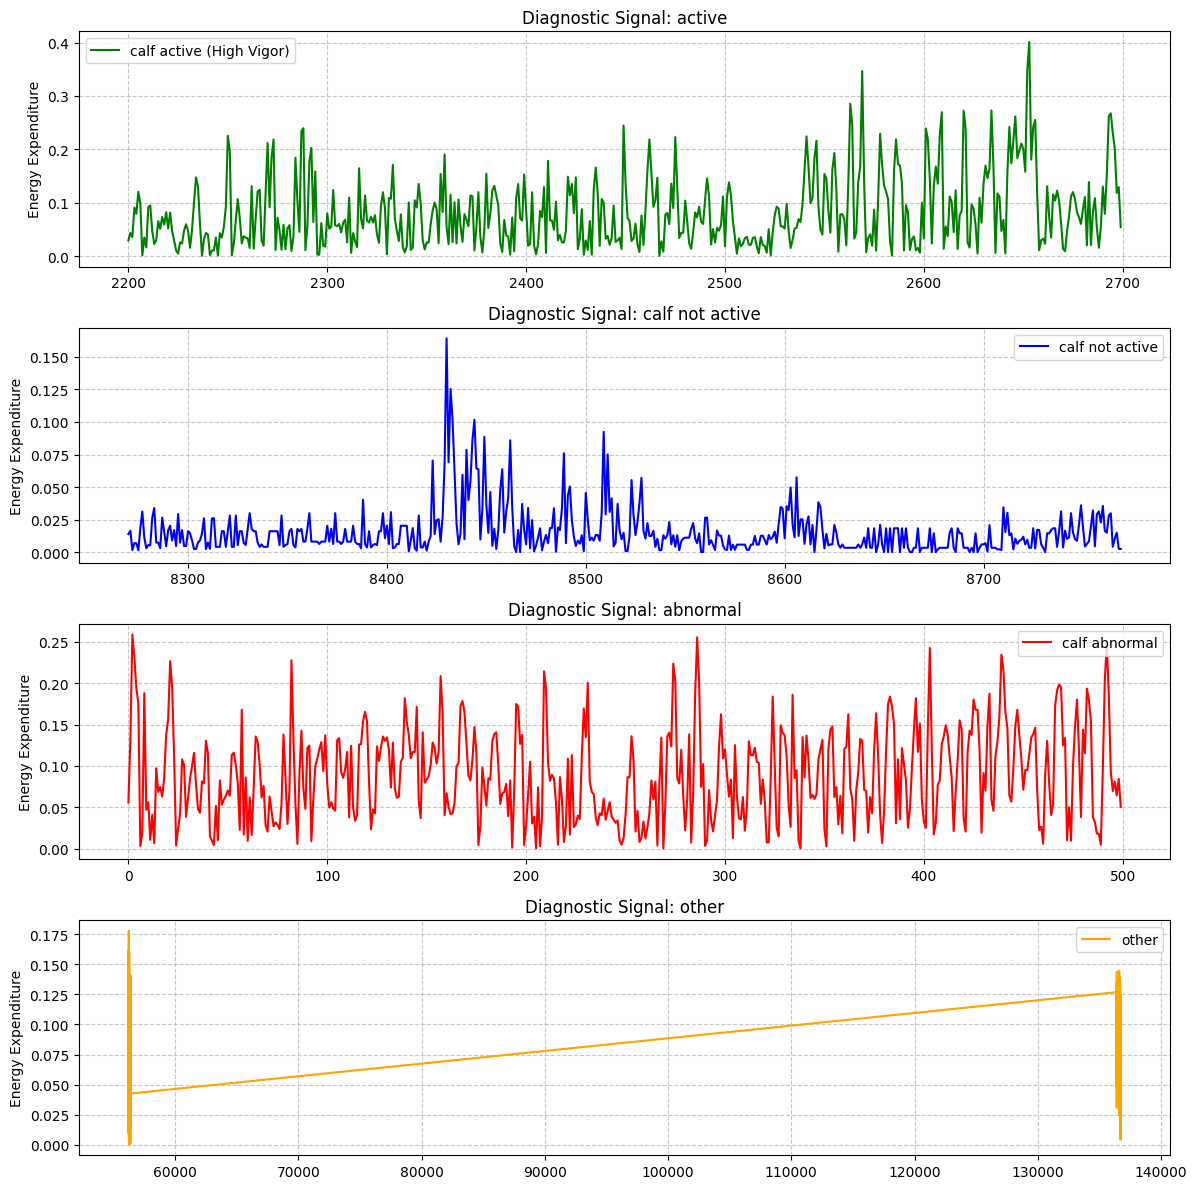

In [32]:
from matplotlib import lines
active = df[df['category'] == 'active'].head(500)
not_active = df[df['category'] == 'not active'].head(500)
abnormal = df[df['category'] == 'abnormal'].head(500)
other = df[df['category'] == 'other'].head(500)

plt.figure(figsize=(12, 12))

plt.subplot(4, 1, 1)
plt.plot(active['energy'], color='green', label='calf active (High Vigor)')
plt.title('Diagnostic Signal: active')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(not_active['energy'], color='blue', label='calf not active')
plt.title('Diagnostic Signal: calf not active')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(abnormal['energy'], color='red', label='calf abnormal')
plt.title('Diagnostic Signal: abnormal')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(other['energy'], color='orange', label='other')
plt.title('Diagnostic Signal: other')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
df['energy_smooth_10'] = df['energy'].rolling(window=10).mean()
df['energy_smooth_20'] = df['energy'].rolling(window=20).mean()

In [34]:
df.head()

,dateTime,calfId,accX,accY,accZ,behaviour,segId,date,time,time_diff,category,acc_mag,energy,energy_smooth_10,energy_smooth_20
0,2022-02-24 00:08:34.402385,1306,0.8125,0.3906,0.2812,oral_manipulation_of_pen,0,2022-02-24,00:08:34.402385,NaN,abnormal,0.9444,0.0556,NaN,NaN
1,2022-02-24 00:08:34.441385,1306,0.6875,0.3750,0.3750,oral_manipulation_of_pen,0,2022-02-24,00:08:34.441385,0.0390,abnormal,0.8683,0.1317,NaN,NaN
2,2022-02-24 00:08:34.481386,1306,0.6250,0.2969,0.2656,oral_manipulation_of_pen,0,2022-02-24,00:08:34.481386,0.0400,abnormal,0.7412,0.2588,NaN,NaN
3,2022-02-24 00:08:34.521386,1306,0.7031,0.2188,0.2188,oral_manipulation_of_pen,0,2022-02-24,00:08:34.521386,0.0400,abnormal,0.7682,0.2318,NaN,NaN
4,2022-02-24 00:08:34.560387,1306,0.7344,0.2188,0.2500,oral_manipulation_of_pen,0,2022-02-24,00:08:34.560387,0.0390,abnormal,0.8060,0.1940,NaN,NaN


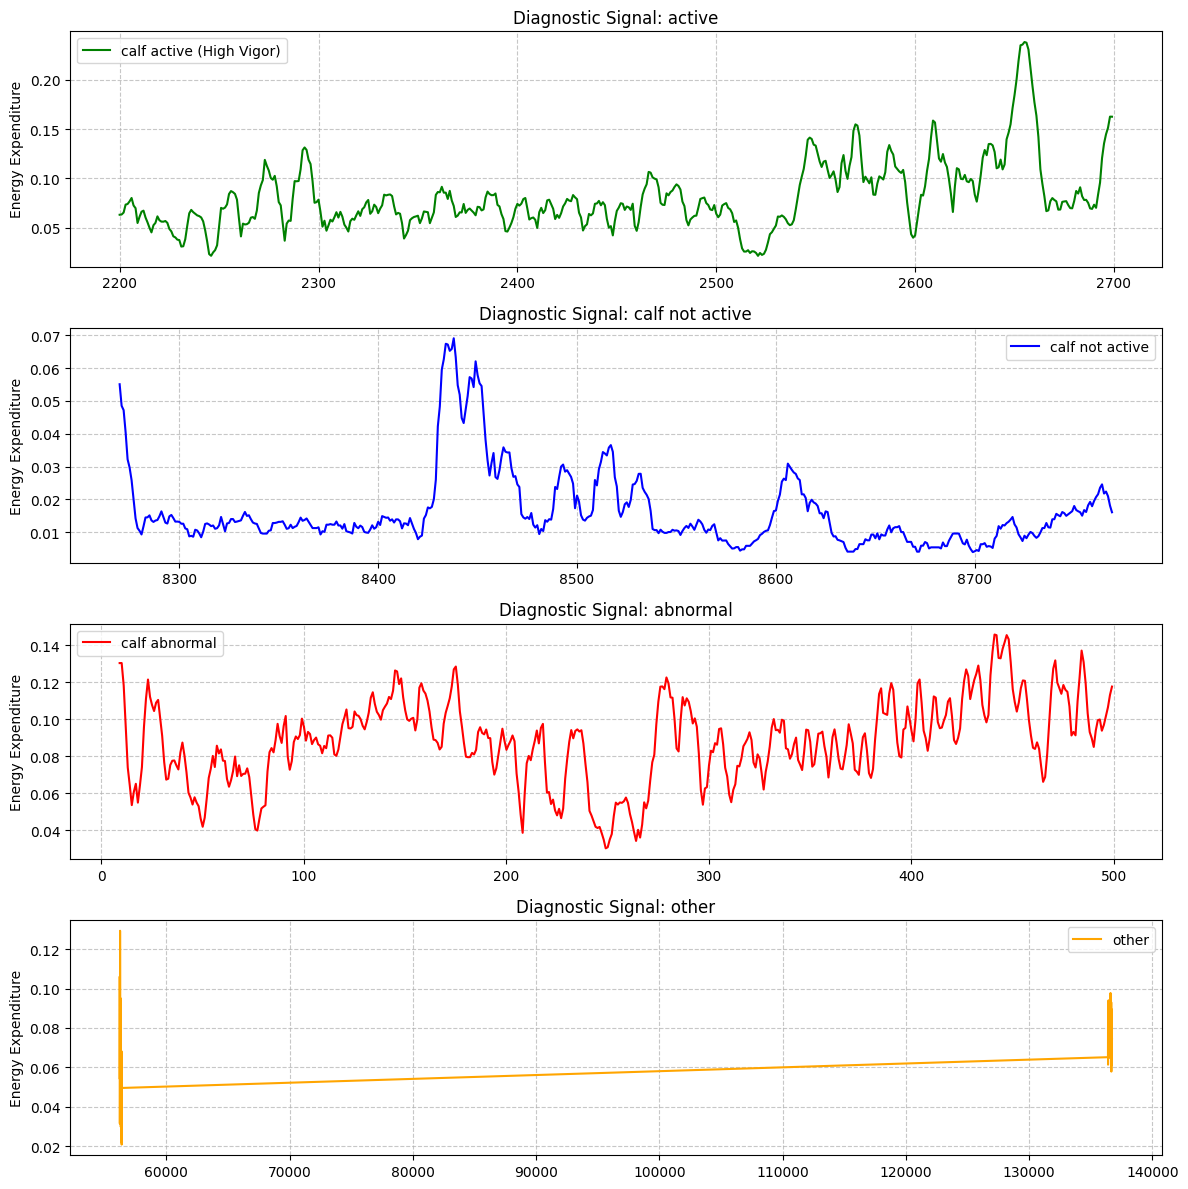

In [35]:
active = df[df['category'] == 'active'].head(500)
not_active = df[df['category'] == 'not active'].head(500)
abnormal = df[df['category'] == 'abnormal'].head(500)
other = df[df['category'] == 'other'].head(500)

plt.figure(figsize=(12, 12))

plt.subplot(4, 1, 1)
plt.plot(active['energy_smooth_10'], color='green', label='calf active (High Vigor)')
plt.title('Diagnostic Signal: active')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(not_active['energy_smooth_10'], color='blue', label='calf not active')
plt.title('Diagnostic Signal: calf not active')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(abnormal['energy_smooth_10'], color='red', label='calf abnormal')
plt.title('Diagnostic Signal: abnormal')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(other['energy_smooth_10'], color='orange', label='other')
plt.title('Diagnostic Signal: other')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

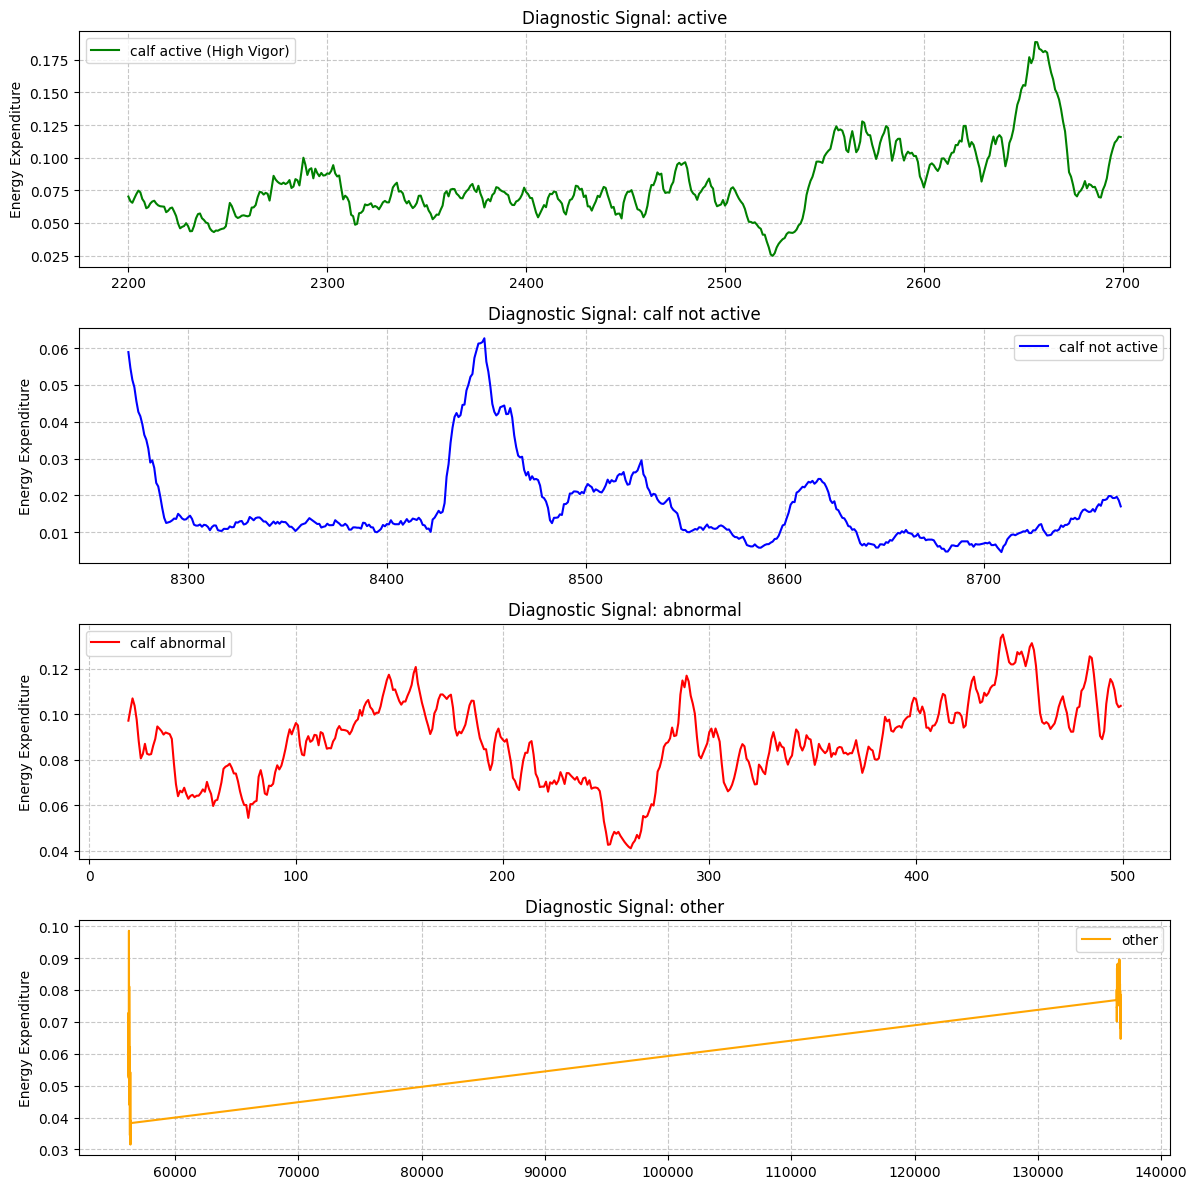

In [36]:
active = df[df['category'] == 'active'].head(500)
not_active = df[df['category'] == 'not active'].head(500)
abnormal = df[df['category'] == 'abnormal'].head(500)
other = df[df['category'] == 'other'].head(500)

plt.figure(figsize=(12, 12))

plt.subplot(4, 1, 1)
plt.plot(active['energy_smooth_20'], color='green', label='calf active (High Vigor)')
plt.title('Diagnostic Signal: active')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(not_active['energy_smooth_20'], color='blue', label='calf not active')
plt.title('Diagnostic Signal: calf not active')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(abnormal['energy_smooth_20'], color='red', label='calf abnormal')
plt.title('Diagnostic Signal: abnormal')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(other['energy_smooth_20'], color='orange', label='other')
plt.title('Diagnostic Signal: other')
plt.ylabel('Energy Expenditure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

**calfId and date**

In [37]:
df.head()

,dateTime,calfId,accX,accY,accZ,behaviour,segId,date,time,time_diff,category,acc_mag,energy,energy_smooth_10,energy_smooth_20
0,2022-02-24 00:08:34.402385,1306,0.8125,0.3906,0.2812,oral_manipulation_of_pen,0,2022-02-24,00:08:34.402385,NaN,abnormal,0.9444,0.0556,NaN,NaN
1,2022-02-24 00:08:34.441385,1306,0.6875,0.3750,0.3750,oral_manipulation_of_pen,0,2022-02-24,00:08:34.441385,0.0390,abnormal,0.8683,0.1317,NaN,NaN
2,2022-02-24 00:08:34.481386,1306,0.6250,0.2969,0.2656,oral_manipulation_of_pen,0,2022-02-24,00:08:34.481386,0.0400,abnormal,0.7412,0.2588,NaN,NaN
3,2022-02-24 00:08:34.521386,1306,0.7031,0.2188,0.2188,oral_manipulation_of_pen,0,2022-02-24,00:08:34.521386,0.0400,abnormal,0.7682,0.2318,NaN,NaN
4,2022-02-24 00:08:34.560387,1306,0.7344,0.2188,0.2500,oral_manipulation_of_pen,0,2022-02-24,00:08:34.560387,0.0390,abnormal,0.8060,0.1940,NaN,NaN


In [38]:
df[['calfId','date']].value_counts().sort_index()

calfId  date      
1302    2022-02-21    80424
        2022-02-22    17300
        2022-02-23    19817
        2022-02-24    19624
1303    2022-02-10    12641
                      ...  
1449    2022-03-31    21453
1452    2022-02-23    82047
1455    2022-02-21    52143
        2022-02-23    35782
        2022-02-25    80471
Name: count, Length: 89, dtype: int64

In [39]:
# Create a 'session_id' that increases whenever a large gap (1 hour = 3600 seconds) is found
df['new_session'] = (df['time_diff'] > 3600).astype(int).cumsum()
df['session_id'] = df['calfId'].astype(str) + "_" + df['new_session'].astype(str)

In [40]:
df.head()

,dateTime,calfId,accX,accY,accZ,behaviour,segId,date,time,time_diff,category,acc_mag,energy,energy_smooth_10,energy_smooth_20,new_session,session_id
0,2022-02-24 00:08:34.402385,1306,0.8125,0.3906,0.2812,oral_manipulation_of_pen,0,2022-02-24,00:08:34.402385,NaN,abnormal,0.9444,0.0556,NaN,NaN,0,1306_0
1,2022-02-24 00:08:34.441385,1306,0.6875,0.3750,0.3750,oral_manipulation_of_pen,0,2022-02-24,00:08:34.441385,0.0390,abnormal,0.8683,0.1317,NaN,NaN,0,1306_0
2,2022-02-24 00:08:34.481386,1306,0.6250,0.2969,0.2656,oral_manipulation_of_pen,0,2022-02-24,00:08:34.481386,0.0400,abnormal,0.7412,0.2588,NaN,NaN,0,1306_0
3,2022-02-24 00:08:34.521386,1306,0.7031,0.2188,0.2188,oral_manipulation_of_pen,0,2022-02-24,00:08:34.521386,0.0400,abnormal,0.7682,0.2318,NaN,NaN,0,1306_0
4,2022-02-24 00:08:34.560387,1306,0.7344,0.2188,0.2500,oral_manipulation_of_pen,0,2022-02-24,00:08:34.560387,0.0390,abnormal,0.8060,0.1940,NaN,NaN,0,1306_0


In [41]:
df['session_id'].value_counts().count()

np.int64(96)

In [45]:
df[['segId','behaviour']].value_counts().sort_index()

,,count
segId,behaviour,
0,oral_manipulation_of_pen,825
1,oral_manipulation_of_pen,557
2,oral_manipulation_of_pen,818
3,grooming,304
4,grooming,241
...,...,...
4011,sniff,178
4012,sniff,80
4013,lying-down,92


In [47]:
cleanup_map = {
    # Resting / Lying (The largest group)
    'lying': 'rest_lying', 'lying-down': 'rest_lying', 'sniff_lying': 'rest_lying',
    'grooming_lying': 'rest_lying', 'rumination_lying': 'rest_lying',
    'social_groom_lying': 'rest_lying', 'social_sniff_lying': 'rest_lying',
    'social_nudge_lying': 'rest_lying', 'tongue_rolling_lying': 'rest_lying',

    # Feeding & Drinking
    'drinking_milk': 'drinking', 'drinking': 'drinking', 'drinking|water': 'drinking',
    'drinking_electrolytes': 'drinking', 'eating_concentrates': 'feeding',
    'eating_forage': 'feeding', 'eating': 'feeding', 'rumination': 'feeding',

    # Social Interaction
    'social_groom': 'social', 'social_sniff': 'social', 'social': 'social',
    'social_nudge': 'social', 'mount': 'social',

    # Exploration & Maintenance
    'sniff': 'exploration', 'sniff_walking': 'exploration', 'grooming': 'maintenance',
    'scratch': 'maintenance', 'rub': 'maintenance', 'grooming|None': 'maintenance',

    # Movement & Play
    'walking': 'locomotion', 'running': 'locomotion', 'backward': 'locomotion',
    'rising': 'locomotion', 'jump': 'play', 'play_object': 'play', 'play': 'play', 'headbutt': 'play',

    # Abnormal / Stereotypies
    'oral_manipulation_of_pen': 'abnormal_oral', 'eating_bedding': 'abnormal_oral',
    'tongue_rolling': 'abnormal_oral', 'cross-suckle_udder': 'abnormal_oral',
    'cross-suckle_other': 'abnormal_oral', 'abnormal': 'abnormal',

    # Physiological / Health
    'urination': 'elimination', 'defecation': 'elimination',
    'cough': 'health_marker', 'SRS': 'health_marker', 'fall': 'health_marker',
    'vocalization': 'communication', 'stretch': 'maintenance', 'standing': 'standing'
}

# 2. Create the new simplified column
df['behaviour_udated'] = df['behaviour'].map(cleanup_map)

In [48]:
df.head()

,dateTime,calfId,accX,accY,accZ,behaviour,segId,date,time,time_diff,category,acc_mag,energy,energy_smooth_10,energy_smooth_20,new_session,session_id,behaviour_udated
0,2022-02-24 00:08:34.402385,1306,0.8125,0.3906,0.2812,oral_manipulation_of_pen,0,2022-02-24,00:08:34.402385,NaN,abnormal,0.9444,0.0556,NaN,NaN,0,1306_0,abnormal_oral
1,2022-02-24 00:08:34.441385,1306,0.6875,0.3750,0.3750,oral_manipulation_of_pen,0,2022-02-24,00:08:34.441385,0.0390,abnormal,0.8683,0.1317,NaN,NaN,0,1306_0,abnormal_oral
2,2022-02-24 00:08:34.481386,1306,0.6250,0.2969,0.2656,oral_manipulation_of_pen,0,2022-02-24,00:08:34.481386,0.0400,abnormal,0.7412,0.2588,NaN,NaN,0,1306_0,abnormal_oral
3,2022-02-24 00:08:34.521386,1306,0.7031,0.2188,0.2188,oral_manipulation_of_pen,0,2022-02-24,00:08:34.521386,0.0400,abnormal,0.7682,0.2318,NaN,NaN,0,1306_0,abnormal_oral
4,2022-02-24 00:08:34.560387,1306,0.7344,0.2188,0.2500,oral_manipulation_of_pen,0,2022-02-24,00:08:34.560387,0.0390,abnormal,0.8060,0.1940,NaN,NaN,0,1306_0,abnormal_oral


In [49]:
df['behaviour_udated'].value_counts()

,count
behaviour_udated,
rest_lying,1009818
abnormal_oral,255769
drinking,228835
feeding,227498
standing,188908
locomotion,164653
exploration,146115
maintenance,132724
social,67846


In [51]:
df.to_csv('Clean_AcTBeCalf.csv')